In [1]:
import os
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from linearmodels.panel import PanelOLS

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway
from scipy.stats.mstats import winsorize

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
# !pip install --upgrade pip
# !pip install linearmodels
# !pip install xlsxwriter

In [3]:
np.random.seed(42)

In [4]:
from utils import *

# EDA

In [6]:
sent_df = pd.read_parquet('sent_growth_fin_risk_10k_10q.parquet')

In [7]:
sent_df.head()

,ACC_NUM,CIK,FILING_DATE,REPORT_TYPE,SIC,industry_code,industry_name,positive_financial_risk,negative_financial_risk,polarity_financial_risk,positive_growth_MB,negative_growth_MB,polarity_growth_MB,positive_growth_llama,negative_growth_llama,polarity_growth_llama
0,0000785161-15-000020,785161,20150302,10K,8060.0,Hlth,"Healthcare, Medical Equipment, and Drugs",0.193584,0.136253,0.057331,0.468322,0.358830,0.109492,0.638184,0.039062,0.599121
1,0001193125-12-084829,23675,20120228,10K,4213.0,None,None,0.180153,0.172863,0.007290,0.673283,0.209770,0.463513,0.250488,0.097824,0.152664
2,0000950133-09-000541,1066104,20090302,10K,8742.0,None,None,0.129925,0.203789,-0.073864,0.560031,0.310484,0.249547,0.023178,0.160187,-0.137009
3,0001144204-11-063803,896747,20111114,10Q,2834.0,Hlth,"Healthcare, Medical Equipment, and Drugs",0.169773,0.200325,-0.030552,0.687675,0.158882,0.528793,0.223200,0.193428,0.029772
4,0001104659-06-016045,929144,20060313,10K,4833.0,Telcm,Telephone and Television Transmission,0.112701,0.251133,-0.138432,0.707108,0.168152,0.538956,0.088135,0.423431,-0.335297


In [8]:
sent_df['year'] = sent_df['FILING_DATE'].apply(lambda x: str(x)[:4])
sent_df['year_month'] = sent_df['FILING_DATE'].astype(str).str[:6]

In [9]:
sent_df[['industry_code', 'industry_name']].drop_duplicates()

,industry_code,industry_name
0,Hlth,"Healthcare, Medical Equipment, and Drugs"
1,None,None
4,Telcm,Telephone and Television Transmission
6,Shops,"Wholesale, Retail, and Some Services (Laundrie..."
7,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of..."
10,Other,Other
13,Money,Finance
14,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile..."
18,Enrgy,"Oil, Gas, and Coal Extraction and Products"
19,BusEq,"Business Equipment -- Computers, Software, and..."


In [10]:
sent_df = sent_df[(sent_df['industry_code'] != 'Money') & (sent_df['industry_code'] != 'Utils')].copy().reset_index(drop=True)

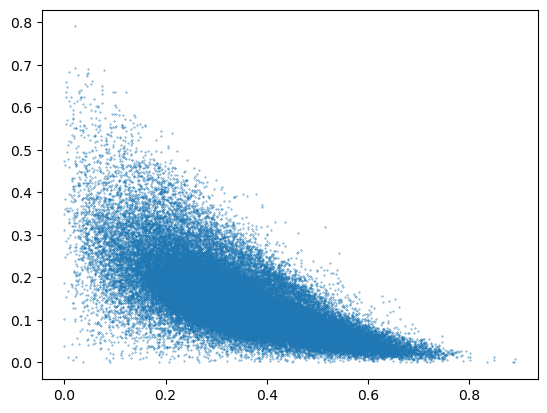

In [11]:
plt.scatter(sent_df['positive_growth_llama'], sent_df['negative_growth_llama'], s=0.1)

In [12]:
sent_df['range_growth_llama'] = sent_df['positive_growth_llama'] + sent_df['negative_growth_llama']

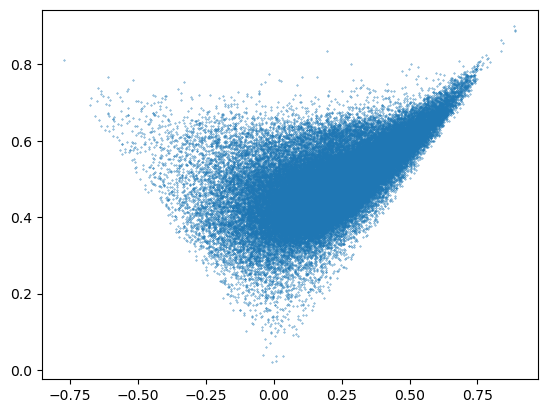

In [15]:
plt.scatter(sent_df['polarity_growth_llama'], sent_df['range_growth_llama'], s=0.1)

In [16]:
ts = sent_df.groupby('year_month').agg(
    {'range_growth_llama': 'mean',
     'polarity_growth_llama': 'mean',
    }
)

ts = ts.reset_index()
ts['year_month'] = pd.to_datetime(ts['year_month'], format='%Y%m')

ts = ts.sort_values('year_month')

window_size = 4

ts['range_growth_llama_4m'] = ts['range_growth_llama'].rolling(window=window_size, center=False).mean()
ts['polarity_growth_llama_4m'] = ts['polarity_growth_llama'].rolling(window=window_size, center=False).mean()

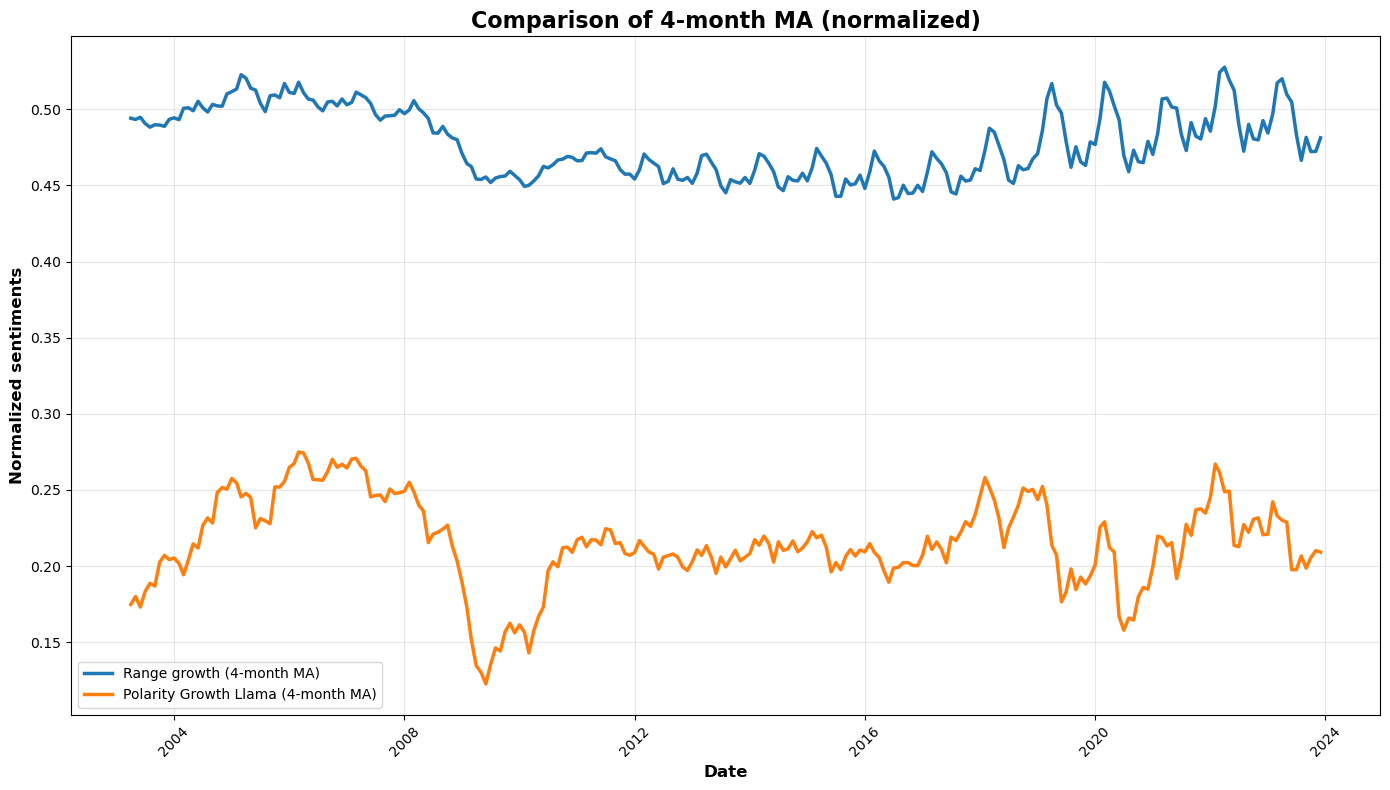

In [17]:
fig = plot_time_series(df=ts, dates=ts['year_month'],
                       cols_to_plot=['range_growth_llama_4m', 'polarity_growth_llama_4m'],
                       cols_labels_dict={
                         'range_growth_llama_4m': 'Range growth (4-month MA)',
                         'polarity_growth_llama_4m': 'Polarity Growth Llama (4-month MA)'
                        },
                       title='Comparison of 4-month MA (normalized)'
                      )

In [18]:
sent_df = sent_df.drop('range_growth_llama', axis=1)

In [19]:
sentiment_cols = [
    'positive_growth_MB', 'negative_growth_MB', 'polarity_growth_MB',
    'positive_growth_llama', 'negative_growth_llama', 'polarity_growth_llama',
]

In [20]:
sent_df[sentiment_cols].corr()

,positive_growth_MB,negative_growth_MB,polarity_growth_MB,positive_growth_llama,negative_growth_llama,polarity_growth_llama
positive_growth_MB,1.000000,-0.771659,0.960516,0.146705,-0.051175,0.119335
negative_growth_MB,-0.771659,1.000000,-0.918151,-0.128649,0.207477,-0.171826
polarity_growth_MB,0.960516,-0.918151,1.000000,0.147667,-0.122642,0.149505
positive_growth_llama,0.146705,-0.128649,0.147667,1.000000,-0.690580,0.954458
negative_growth_llama,-0.051175,0.207477,-0.122642,-0.690580,1.000000,-0.874910
polarity_growth_llama,0.119335,-0.171826,0.149505,0.954458,-0.874910,1.000000


In [21]:
ts_df = sent_df.groupby('year_month').agg(
    {'negative_growth_MB': 'mean',
     'positive_growth_MB': 'mean',
     'polarity_growth_MB': 'mean',
     'negative_growth_llama': 'mean',
     'positive_growth_llama': 'mean',
     'polarity_growth_llama': 'mean',
    }
)

ts_df = ts_df.reset_index()

In [22]:
ts_df.head()

,year_month,negative_growth_MB,positive_growth_MB,polarity_growth_MB,negative_growth_llama,positive_growth_llama,polarity_growth_llama
0,200301,0.227838,0.592144,0.364306,0.156156,0.332257,0.176101
1,200302,0.243460,0.579181,0.335721,0.151144,0.338431,0.187286
2,200303,0.261293,0.598821,0.337528,0.175105,0.328980,0.153875
3,200304,0.223332,0.603504,0.380171,0.156367,0.338215,0.181847
4,200305,0.238639,0.565628,0.326988,0.144045,0.340987,0.196942


In [23]:
# jiang management sentiment index
jlmz_sent = pd.read_excel('JLMZ_MS_Index2017.xlsx')

jlmz_sent['year_month'] = jlmz_sent['date'].str.replace('-', '')
jlmz_sent.drop('date', axis=1, inplace=True)
jlmz_sent = jlmz_sent.rename(columns={'Manager Sentiment Index': 'msi'})

df = jlmz_sent.merge(ts_df, on='year_month', how='right')

In [24]:
df[['msi', 'polarity_growth_MB', 'polarity_growth_llama']].corr()

,msi,polarity_growth_MB,polarity_growth_llama
msi,1.000000,-0.111873,0.335431
polarity_growth_MB,-0.111873,1.000000,0.081730
polarity_growth_llama,0.335431,0.081730,1.000000


In [25]:
df['year_month'] = pd.to_datetime(df['year_month'], format='%Y%m')

df = df.sort_values('year_month')

window_size = 4

df['msi_ma_4m'] = df['msi'].rolling(window=window_size, center=False).mean()
df['negative_growth_MB_ma_4m'] = df['negative_growth_MB'].rolling(window=window_size, center=False).mean()
df['positive_growth_MB_ma_4m'] = df['positive_growth_MB'].rolling(window=window_size, center=False).mean()
df['polarity_growth_MB_ma_4m'] = df['polarity_growth_MB'].rolling(window=window_size, center=False).mean()

df['negative_growth_llama_ma_4m'] = df['negative_growth_llama'].rolling(window=window_size, center=False).mean()
df['positive_growth_llama_ma_4m'] = df['positive_growth_llama'].rolling(window=window_size, center=False).mean()
df['polarity_growth_llama_ma_4m'] = df['polarity_growth_llama'].rolling(window=window_size, center=False).mean()

In [26]:
# df[df['year_month'].between('2003-01-01', '2014-12-31')]['msi'].describe()

In [27]:
scaler = StandardScaler()
data_to_normalize = df[['msi_ma_4m', 'negative_growth_llama_ma_4m',
                        'positive_growth_llama_ma_4m', 'polarity_growth_llama_ma_4m']].dropna()
normalized_data = scaler.fit_transform(data_to_normalize)

normalized_df = pd.DataFrame(normalized_data, 
                            columns=['msi_ma_4m_norm', 'negative_growth_llama_ma_4m_norm', 
                                     'positive_growth_llama_ma_4m_norm', 'polarity_growth_llama_ma_4m_norm'],
                            index=data_to_normalize.index)

dates_for_normalized = df.loc[normalized_df.index, 'year_month']
normalized_df['year_month'] = dates_for_normalized

normalized_df = normalized_df.reset_index(drop=True)

In [28]:
normalized_df[['msi_ma_4m_norm', 'polarity_growth_llama_ma_4m_norm']].corr()

,msi_ma_4m_norm,polarity_growth_llama_ma_4m_norm
msi_ma_4m_norm,1.000000,0.463363
polarity_growth_llama_ma_4m_norm,0.463363,1.000000


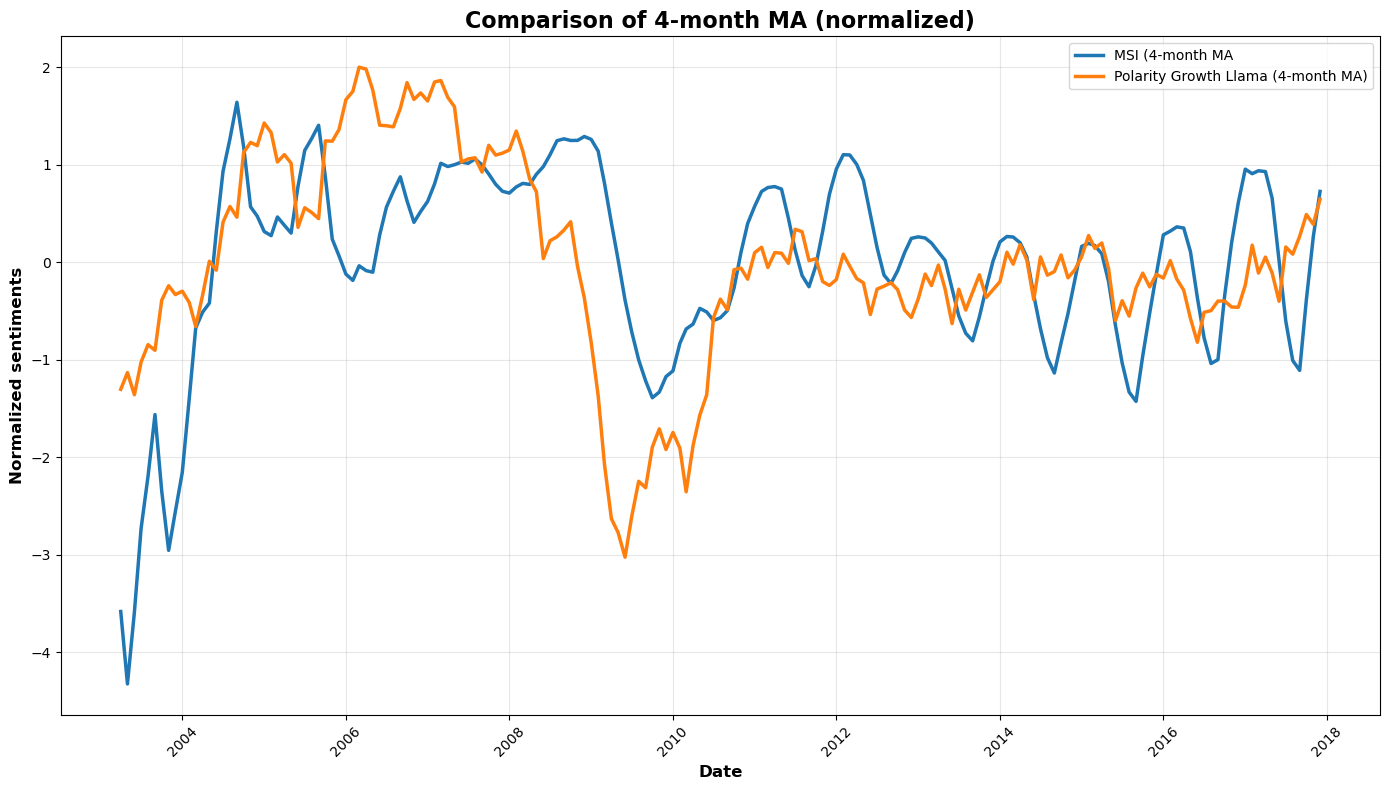

In [29]:
fig = plot_time_series(df=normalized_df, dates=dates_for_normalized,
                       cols_to_plot=['msi_ma_4m_norm', 'polarity_growth_llama_ma_4m_norm'],
                       cols_labels_dict={
                         'msi_ma_4m_norm': 'MSI (4-month MA',
                         'polarity_growth_llama_ma_4m_norm': 'Polarity Growth Llama (4-month MA)'
                        },
                       title='Comparison of 4-month MA (normalized)'
                      )

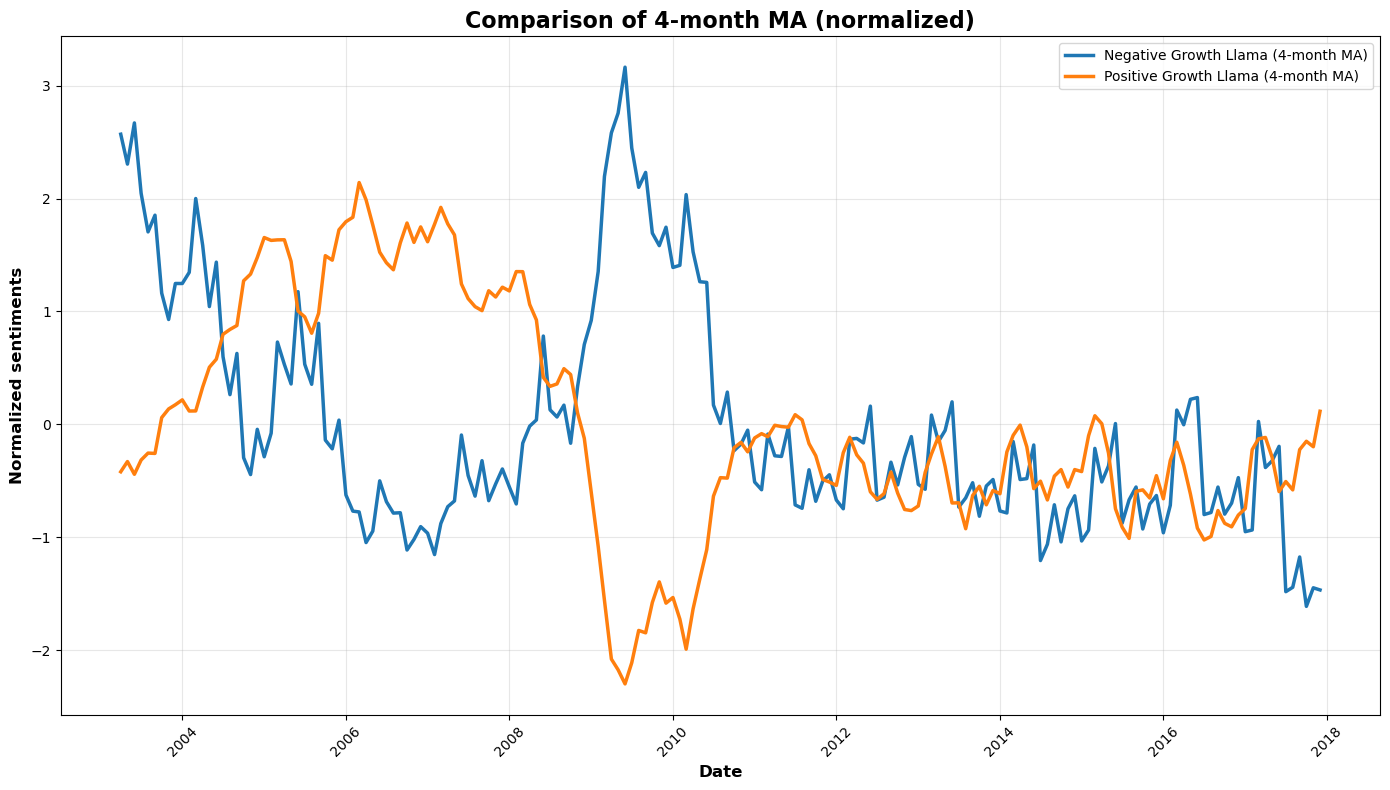

In [30]:
fig = plot_time_series(df=normalized_df, dates=dates_for_normalized,
                       cols_to_plot=['negative_growth_llama_ma_4m_norm', 'positive_growth_llama_ma_4m_norm'],
                       cols_labels_dict={
                         'negative_growth_llama_ma_4m_norm': 'Negative Growth Llama (4-month MA)',
                         'positive_growth_llama_ma_4m_norm': 'Positive Growth Llama (4-month MA)'
                        },
                      )

# Models

Rmt+1 (the monthly return on the S&P 500 index in excess of the risk-free rate

In [31]:
predictor_data = pd.read_excel('PredictorData2024.xlsx')

In [32]:
predictor_data.tail()

,yyyymm,Index,D12,E12,b/m,tbl,AAA,BAA,lty,ntis,Rfree,infl,ltr,corpr,svar,csp,CRSP_SPvw,CRSP_SPvwx
1843,202408,5648.40,72.925466,198.823333,0.187377,0.0505,0.0487,0.0560,0.0387,-0.011028,0.0048,0.000814,0.012792,0.015726,0.003184,NaN,0.024283,0.022898
1844,202409,5762.48,73.400300,200.270000,0.183981,0.0472,0.0468,0.0542,0.0372,-0.010283,0.0040,0.001604,0.012023,0.017730,0.001466,NaN,0.022821,0.021707
1845,202410,5705.45,73.877618,203.570000,0.186478,0.0451,0.0495,0.0563,0.0410,-0.009458,0.0039,0.001151,-0.023811,-0.024271,0.001062,NaN,-0.008690,-0.009523
1846,202411,6032.38,74.354936,206.870000,0.173410,0.0442,0.0514,0.0578,0.0436,-0.004121,0.0040,-0.000542,0.007772,0.013377,0.001264,NaN,0.060420,0.059016
1847,202412,5881.63,74.832255,210.170000,0.183056,0.0427,0.0520,0.0580,0.0439,-0.004614,0.0037,0.000355,-0.015408,-0.019354,0.001643,NaN,-0.023445,-0.024621


In [33]:
# plt.plot(predictor_data['yyyymm'], predictor_data['Index'])

In [34]:
data = predictor_data[predictor_data['yyyymm'] > 200211].copy().reset_index(drop=True)
data['year_month'] = pd.to_datetime(data['yyyymm'], format='%Y%m')

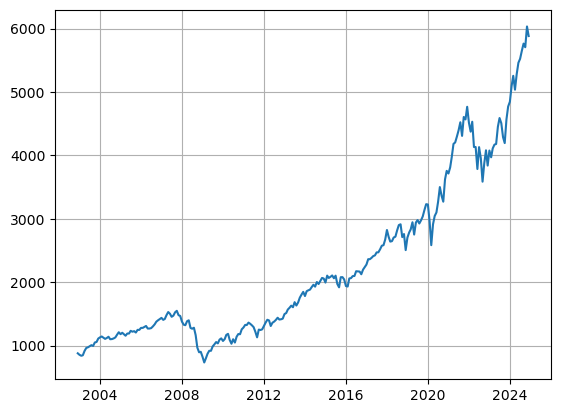

In [35]:
plt.plot(data['year_month'], data['Index'])
plt.grid()

In [36]:
data = data.sort_values('year_month')
data['index_return'] = data['Index'].pct_change()
data['target'] = data['index_return'] - data['Rfree']

data = data.merge(normalized_df, on='year_month', how='left')

In [37]:
# data['log_index'] = np.log(data['Index']).diff() - data['Rfree']
# data[['log_index', 'target']].corr()
# it's the same

In [38]:
data.head()

,yyyymm,Index,D12,E12,b/m,tbl,AAA,BAA,lty,ntis,Rfree,infl,ltr,corpr,svar,csp,CRSP_SPvw,CRSP_SPvwx,year_month,index_return,target,msi_ma_4m_norm,negative_growth_llama_ma_4m_norm,positive_growth_llama_ma_4m_norm,polarity_growth_llama_ma_4m_norm
0,200212,879.82,16.074000,27.59,0.295386,0.0119,0.0621,0.0745,0.0484,0.025736,0.0011,-0.002206,0.0507,0.0361,0.002640,-0.004144,-0.058834,-0.060464,2002-12-01,NaN,NaN,NaN,NaN,NaN,NaN
1,200301,855.70,16.124000,28.50,0.305942,0.0117,0.0617,0.0735,0.0495,0.028289,0.0010,0.004422,-0.0106,0.0021,0.005168,NaN,-0.026579,-0.027860,2003-01-01,-0.027415,-0.028415,NaN,NaN,NaN,NaN
2,200302,841.15,16.174000,29.41,0.312251,0.0117,0.0595,0.0706,0.0472,0.027919,0.0009,0.007705,0.0329,0.0264,0.002564,NaN,-0.015246,-0.017225,2003-02-01,-0.017004,-0.017904,NaN,NaN,NaN,NaN
3,200303,848.18,16.224000,30.32,0.286118,0.0113,0.0589,0.0695,0.0486,0.024099,0.0010,0.006008,-0.0135,-0.0080,0.006136,NaN,0.010308,0.008967,2003-03-01,0.008358,0.007358,NaN,NaN,NaN,NaN
4,200304,916.92,16.204333,31.73,0.269654,0.0113,0.0574,0.0685,0.0481,0.019967,0.0010,-0.002172,0.0102,0.0229,0.003065,NaN,0.082774,0.081462,2003-04-01,0.081044,0.080044,-3.584048,2.570217,-0.42001,-1.304779


### Control variables

we use 14 monthly economic variables that are linked directly to macroeconomic fundamentals, which are 
- the log dividend-price ratio (DP): log of a 12-month moving sum of dividends paid on the S&P 500 index minus the log of stock prices (S&P 500 index) 
- log dividend yield (DY): difference between the log of dividends and the log of lagged prices
- log earnings-price ratio (EP): difference between the log of earnings on the S&P 500 index and the log of prices, where earnings is measured using a one-year moving sum 
- log dividend-payout ratio (DE): difference between the log of dividends and the log of earnings on the S&P 500 index
- stock return variance (SVAR),
- book-to-market ratio (BM),
- net equity expansion (NTIS),
- Treasury bill rate (TBL), 
- long-term bond yield (LTY),
- long-term bond return (LTR), 
- term spread (TMS): difference between the long-term yield and the Treasury bill rate
- default yield spread (DFY): difference between BAA- and AAA-rated corporate bond yields
- default return spread (DFR): difference between the long-term corporate bond return and the long-term government bond return.
- inflation rate (INFL).

In [39]:
data['log_DP'] = np.log(data['D12']) - np.log(data['Index'])

data['lag_Index'] = data['Index'].shift(1)
data['log_DY'] = np.log(data['D12']) - np.log(data['lag_Index'])

data['log_EP'] = np.log(data['E12']) - np.log(data['Index'])
data['log_DE'] = np.log(data['D12']) - np.log(data['E12'])
data['tms'] = data['lty'] - data['tbl']
data['dfy'] = data['BAA'] - data['AAA']
data['dfr'] = data['corpr'] - data['ltr']

data = data.rename(columns={'b/m': 'bm'})

In [40]:
# control_variables = ['log_DP', 'log_DY', 'log_EP', 'log_DE', 'svar', 'b/m', 'ntis', 'tbl', 'lty', 'ltr', 'tms', 'dfy', 'dfr', 'infl']
control_variables = ['log_DP', 'log_EP', 'svar', 'bm', 'ntis', 'tbl', 'lty', 'ltr', 'tms', 'dfy', 'dfr', 'infl']
len(control_variables)

12

In [41]:
data[control_variables].describe()

,log_DP,log_EP,svar,bm,ntis,tbl,lty,ltr,tms,dfy,dfr,infl
count,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000
mean,-3.989553,-3.122190,0.002939,0.284885,-0.006511,0.015557,0.034194,0.004385,0.018636,0.010253,0.000647,0.002102
std,0.172141,0.353958,0.006649,0.059840,0.016852,0.017921,0.012188,0.030807,0.015737,0.004121,0.019313,0.003945
min,-4.396047,-4.836478,0.000150,0.173410,-0.055954,0.000100,0.006200,-0.112400,-0.015700,0.005500,-0.097600,-0.019153
25%,-4.074094,-3.201425,0.000746,0.238168,-0.017425,0.000900,0.025800,-0.015330,0.005800,0.007900,-0.006600,-0.000354
50%,-3.973667,-3.086025,0.001363,0.286118,-0.008504,0.009000,0.034900,0.002438,0.019200,0.009300,0.000700,0.002017
75%,-3.899373,-2.911181,0.002705,0.330671,0.007936,0.023900,0.044900,0.023000,0.032300,0.011300,0.008000,0.004741
max,-3.281006,-2.565551,0.073153,0.446141,0.028289,0.053400,0.054200,0.144300,0.045300,0.033800,0.073700,0.013736


In [42]:
data[control_variables].corr()

,log_DP,log_EP,svar,bm,ntis,tbl,lty,ltr,tms,dfy,dfr,infl
log_DP,1.000000,-0.270335,0.389299,0.755450,-0.401352,-0.420511,-0.045138,0.117388,0.443922,0.724724,-0.039346,-0.287781
log_EP,-0.270335,1.000000,-0.184919,0.049014,0.249237,0.108182,0.068357,0.070199,-0.070259,-0.527193,-0.219181,-0.000252
svar,0.389299,-0.184919,1.000000,0.156341,-0.238764,-0.129036,-0.062083,0.205030,0.098866,0.512920,-0.366515,-0.284670
bm,0.755450,0.049014,0.156341,1.000000,0.109420,-0.470258,0.118737,0.107927,0.627488,0.426404,-0.008101,-0.200219
ntis,-0.401352,0.249237,-0.238764,0.109420,1.000000,-0.231569,0.103314,0.017893,0.343724,-0.451915,0.039535,0.117523
tbl,-0.420511,0.108182,-0.129036,-0.470258,-0.231569,1.000000,0.508336,-0.005418,-0.745119,-0.188836,-0.037914,0.064805
lty,-0.045138,0.068357,-0.062083,0.118737,0.103314,0.508336,1.000000,-0.049977,0.195563,0.042768,-0.019754,0.022932
ltr,0.117388,0.070199,0.205030,0.107927,0.017893,-0.005418,-0.049977,1.000000,-0.032535,0.069529,-0.396099,-0.265620
tms,0.443922,-0.070259,0.098866,0.627488,0.343724,-0.745119,0.195563,-0.032535,1.000000,0.248170,0.027878,-0.056040
dfy,0.724724,-0.527193,0.512920,0.426404,-0.451915,-0.188836,0.042768,0.069529,0.248170,1.000000,0.093000,-0.267343


## Table 2 from paper

In [43]:
target = 'target'

In [44]:
data[f'index_return'] = data['Index'].pct_change(periods=1)
data['index_return'] = (data['index_return'] - data['Rfree'])

data['cum_return'] = (1 + data['index_return']).cumprod()
data['net_cum_return'] = data['cum_return'] - 1

In [45]:
return_names = []

for period in [1, 3, 6, 9, 12, 24, 36]:
    return_names.append(f'net_cum_return{period}')

In [46]:
for i in data.index:
    
    working_data = data.loc[i:i+37].copy()
    working_data['net_cum_return'] = (1 + working_data['index_return']).cumprod() - 1

    for period in [1, 3, 6, 9, 12, 24, 36]:

        working_data[f'net_cum_return{period}'] = working_data['net_cum_return'].shift(periods=-period)
    
    data.loc[i, return_names] = working_data[return_names].iloc[0]

In [47]:
# data[return_names] = data[return_names] * 100

In [48]:
data = data.merge(df, on='year_month', how='left')

In [49]:
for sentiment in ['msi', 'polarity_growth_MB', 'polarity_growth_llama', 'negative_growth_llama', 'positive_growth_llama']:

    ss = StandardScaler()
    data[f"{sentiment}_norm"] = ss.fit_transform(data[[sentiment]])

In [50]:
# [col for col in data.columns if 'msi' in col]

In [51]:
[col for col in data.columns if 'llama' in col]

['negative_growth_llama_ma_4m_norm',
 'positive_growth_llama_ma_4m_norm',
 'polarity_growth_llama_ma_4m_norm',
 'negative_growth_llama',
 'positive_growth_llama',
 'polarity_growth_llama',
 'negative_growth_llama_ma_4m',
 'positive_growth_llama_ma_4m',
 'polarity_growth_llama_ma_4m',
 'polarity_growth_llama_norm',
 'negative_growth_llama_norm',
 'positive_growth_llama_norm']

In [52]:
res = ols_new_west(data, x_vars=['msi_norm'], target='net_cum_return1')
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:        net_cum_return1   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     4.224
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0413
Time:                        21:15:26   Log-Likelihood:                 263.80
No. Observations:                 180   AIC:                            -523.6
Df Residuals:                     178   BIC:                            -517.2
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0127      0.006      2.240      0.0

In [53]:
# Period from jiang paper
data_ = data[data['yyyymm'].between(200301, 201412)].copy().reset_index(drop=True)

In [54]:
# Replicate the results from Jiang
features_res, table_res = fit_one_factor(data_, 'msi_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.018**,-2.403,9.079,0.016
net_cum_return3,-0.035***,-2.689,15.392,0.007
net_cum_return6,-0.049***,-2.577,15.59,0.01
net_cum_return9,-0.063***,-2.815,17.681,0.005
net_cum_return12,-0.065***,-2.567,14.847,0.01
net_cum_return24,-0.074*,-1.949,8.831,0.051
net_cum_return36,-0.081**,-2.037,6.883,0.042


In [55]:
features_res, table_res = fit_one_factor(data_, 'polarity_growth_MB_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,0.011*,1.851,1.458,0.064
net_cum_return3,0.01,1.162,0.144,0.245
net_cum_return6,0.005,0.358,-0.599,0.72
net_cum_return9,0.016,0.986,0.025,0.324
net_cum_return12,0.013,0.785,-0.313,0.433
net_cum_return24,0.002,0.089,-0.7,0.929
net_cum_return36,-0.013,-0.307,-0.583,0.759


In [56]:
features_res, table_res = fit_one_factor(data_, 'polarity_growth_llama_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.012**,-2.336,3.553,0.019
net_cum_return3,-0.024**,-2.494,7.134,0.013
net_cum_return6,-0.044***,-2.827,12.49,0.005
net_cum_return9,-0.063***,-3.1,17.782,0.002
net_cum_return12,-0.083***,-3.331,24.698,0.001
net_cum_return24,-0.152***,-4.08,38.682,0.0
net_cum_return36,-0.202***,-5.408,46.531,0.0


In [58]:
features_res, table_res = fit_one_factor(data_, 'positive_growth_llama_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.012**,-2.291,3.316,0.022
net_cum_return3,-0.025***,-2.61,7.743,0.009
net_cum_return6,-0.045***,-2.828,13.608,0.005
net_cum_return9,-0.065***,-2.943,19.552,0.003
net_cum_return12,-0.086***,-3.089,27.68,0.002
net_cum_return24,-0.159***,-3.99,44.622,0.0
net_cum_return36,-0.224***,-6.589,59.661,0.0


In [59]:
# whole sample
features_res, table_res = fit_one_factor(data, 'polarity_growth_llama_ma_4m', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.517***,-3.477,5.724,0.001
net_cum_return3,-0.912***,-3.218,9.351,0.001
net_cum_return6,-1.643***,-3.448,16.88,0.001
net_cum_return9,-2.3***,-3.546,21.991,0.0
net_cum_return12,-2.868***,-3.659,26.481,0.0
net_cum_return24,-4.376***,-3.54,32.588,0.0
net_cum_return36,-5.237***,-3.206,33.518,0.001


In [63]:
# res_ = ols_new_west(data_, x_vars=['negative_growth_llama_norm', 'positive_growth_llama_norm'], target='net_cum_return1')
# print(res_.summary())

## Uncertainty regression with VIX 
VIX + growth sentiment + interaction)

In [64]:
vix = pd.read_csv('VIX_History.csv')

In [65]:
vix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9147 entries, 0 to 9146
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    9147 non-null   object 
 1   OPEN    9147 non-null   float64
 2   HIGH    9147 non-null   float64
 3   LOW     9147 non-null   float64
 4   CLOSE   9147 non-null   float64
dtypes: float64(4), object(1)
memory usage: 357.4+ KB


In [66]:
vix['DATE'] = pd.to_datetime(vix['DATE'])
vix['year_month'] = vix['DATE'].astype(str).str[:7]

ss = StandardScaler()
vix['close_norm'] = ss.fit_transform(vix[['CLOSE']])

In [67]:
vix.describe(percentiles=[0.1, 0.9]).round(2)

,DATE,OPEN,HIGH,LOW,CLOSE,close_norm
count,9147,9147.00,9147.00,9147.00,9147.00,9147.00
mean,2008-02-22 18:03:53.781567744,19.54,20.38,18.77,19.45,-0.00
min,1990-01-02 00:00:00,2.58,9.31,8.56,9.14,-1.33
10%,1993-08-14 19:12:00,12.16,12.67,11.75,12.14,-0.94
50%,2008-02-27 00:00:00,17.66,18.34,16.99,17.60,-0.24
90%,2022-09-01 09:36:00,28.75,29.90,27.57,28.58,1.18
max,2026-03-20 00:00:00,82.69,89.53,72.76,82.69,8.15
std,NaN,7.84,8.32,7.29,7.76,1.00


In [70]:
vix_df = vix.groupby('year_month').agg(
    {'close_norm': 'mean',}
)
vix_df.columns = ['vix_norm']

vix_df = vix_df.reset_index()
vix_df['year_month'] = pd.to_datetime(vix_df['year_month'])

In [71]:
vix_df.tail()

,year_month,vix_norm
430,2025-11-01,0.041269
431,2025-12-01,-0.502640
432,2026-01-01,-0.421354
433,2026-02-01,-0.031209
434,2026-03-01,0.675265


In [72]:
data_v = data.merge(vix_df, on='year_month', how='left')

In [73]:
data_v['sent_vix'] = data_v['polarity_growth_llama_norm'] * data_v['vix_norm']

In [74]:
features_res, table_res = fit_one_factor(data_v, 'polarity_growth_llama_norm', return_names, ['vix_norm', 'sent_vix'])
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.015***,-4.111,15.025,0.0
net_cum_return3,-0.026***,-4.173,16.891,0.0
net_cum_return6,-0.035***,-3.765,18.976,0.0
net_cum_return9,-0.049***,-3.902,22.824,0.0
net_cum_return12,-0.064***,-3.662,26.609,0.0
net_cum_return24,-0.103***,-3.214,25.608,0.001
net_cum_return36,-0.123***,-2.782,26.831,0.005


In [75]:
res_v = ols_new_west(data_v, x_vars=['polarity_growth_llama_norm', 'vix_norm', 'sent_vix'], target='net_cum_return12')
print(res_v.summary())

                            OLS Regression Results                            
Dep. Variable:       net_cum_return12   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     8.868
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.32e-05
Time:                        21:16:17   Log-Likelihood:                 142.68
No. Observations:                 252   AIC:                            -277.4
Df Residuals:                     248   BIC:                            -263.2
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

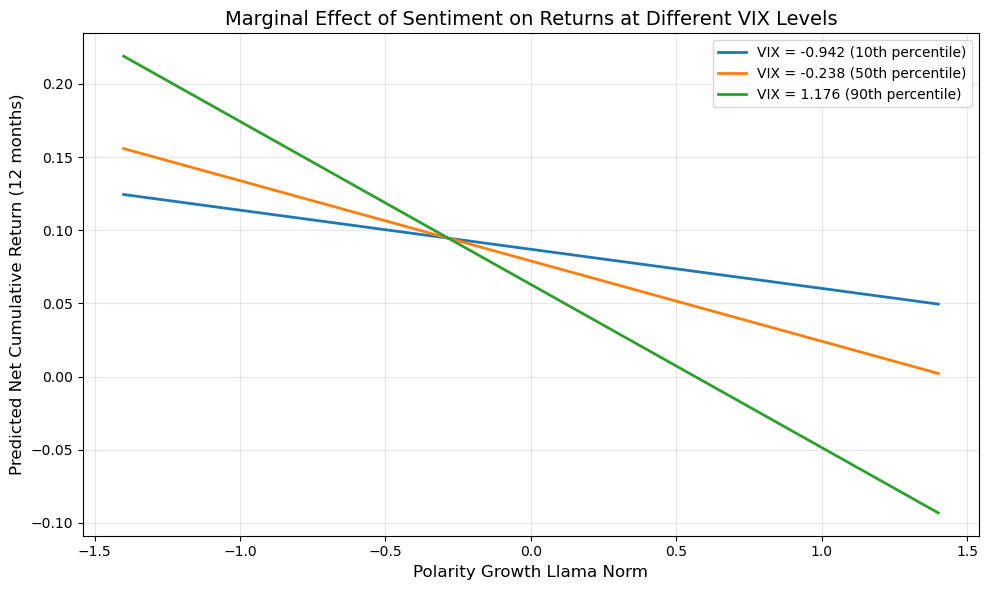

In [76]:
plot_prediction_for_different_risks(df=vix, 
                                    model_results=res_v,
                                    x_vars=['polarity_growth_llama_norm', 'vix_norm', 'sent_vix'],
                                    risk_col='close_norm',
                                    polarity_values=np.linspace(-1.4, 1.4, 100),
                                    risk_name='VIX',
                                    xlabel='Polarity Growth Llama Norm',
                                    ylabel='Predicted Net Cumulative Return (12 months)'
                                   )

## Uncertainty regression with NVIX 

NVIX + growth sentiment + interaction

In [77]:
nvix = pd.read_excel('nvix_and_categories_timeseries_mar2016.xlsx', sheet_name='news_implied_volatility')

nvix['DATE'] = pd.to_datetime(nvix['Date'], format='%Y%m%d')
nvix['year_month'] = nvix['DATE'].astype(str).str[:7]

In [78]:
nvix

,Date,NVIX,Government,Intermediation,Natural Disaster,Securities Markets,War,Unclassified,DATE,year_month
0,18890731,35.131129,1.581324,1.669112,-0.001938,8.948479,0.053292,10.165502,1889-07-31,1889-07
1,18890831,32.034896,1.401852,1.638029,0.000000,5.015624,0.039735,11.149588,1889-08-31,1889-08
2,18890930,34.186390,0.848929,1.518191,0.000000,5.757074,0.071911,13.189975,1889-09-30,1889-09
3,18891031,38.383016,1.188763,2.354759,-0.000532,5.587853,0.056797,16.466273,1889-10-31,1889-10
4,18891130,34.703040,0.821947,2.175272,-0.091721,5.162286,0.056355,13.875538,1889-11-30,1889-11
...,...,...,...,...,...,...,...,...,...,...
1516,20151130,27.433962,0.733991,1.129307,0.004585,0.927936,-0.219399,12.108684,2015-11-30,2015-11
1517,20151231,29.158919,0.876202,1.283003,0.007064,2.243764,0.026586,11.995910,2015-12-31,2015-12
1518,20160131,33.681709,0.548687,1.636443,0.005722,4.610633,-0.017490,14.202225,2016-01-31,2016-01
1519,20160229,29.648414,0.388820,1.280814,-0.069879,3.135675,0.016873,12.209995,2016-02-29,2016-02


In [79]:
ss = StandardScaler()
nvix['nvix_norm'] = ss.fit_transform(nvix[['NVIX']])

In [80]:
nvix[['NVIX', 'nvix_norm']].describe(percentiles=[0.1, 0.9]).round(2)

,NVIX,nvix_norm
count,1514.00,1514.00
mean,25.32,0.00
std,4.37,1.00
min,13.62,-2.68
10%,20.05,-1.21
50%,25.24,-0.02
90%,30.38,1.16
max,57.90,7.46


In [81]:
# mask = ~nvix['nvix_norm'].isnull()

In [82]:
vix_df = nvix.groupby('year_month').agg(
    {'nvix_norm': 'mean',}
)
vix_df.columns = ['nvix_norm']

vix_df = vix_df.reset_index()
vix_df['year_month'] = pd.to_datetime(vix_df['year_month'])

In [83]:
vix_df.tail()

,year_month,nvix_norm
1516,2015-11-01,0.483562
1517,2015-12-01,0.878823
1518,2016-01-01,1.915186
1519,2016-02-01,0.990987
1520,2016-03-01,0.182132


In [84]:
data_v = data.merge(vix_df, on='year_month', how='left')
data_v['sent_nvix'] = data_v['polarity_growth_llama_norm'] * data_v['nvix_norm']

In [85]:
features_res, table_res = fit_one_factor(data_v, 'polarity_growth_llama_norm', return_names, ['nvix_norm', 'sent_nvix'])
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.026***,-3.009,17.529,0.003
net_cum_return3,-0.038**,-2.36,15.668,0.018
net_cum_return6,-0.053***,-2.735,19.722,0.006
net_cum_return9,-0.066***,-2.917,25.64,0.004
net_cum_return12,-0.082***,-2.975,31.328,0.003
net_cum_return24,-0.114***,-2.873,41.559,0.004
net_cum_return36,-0.136***,-3.089,57.731,0.002


In [86]:
res_v = ols_new_west(data_v, x_vars=['polarity_growth_llama_norm', 'nvix_norm', 'sent_nvix'], target='net_cum_return12')
print(res_v.summary())

                            OLS Regression Results                            
Dep. Variable:       net_cum_return12   R-squared:                       0.326
Model:                            OLS   Adj. R-squared:                  0.313
Method:                 Least Squares   F-statistic:                     9.980
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           4.71e-06
Time:                        21:16:36   Log-Likelihood:                 91.368
No. Observations:                 159   AIC:                            -174.7
Df Residuals:                     155   BIC:                            -162.5
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [87]:
mask = ~nvix['nvix_norm'].isnull()

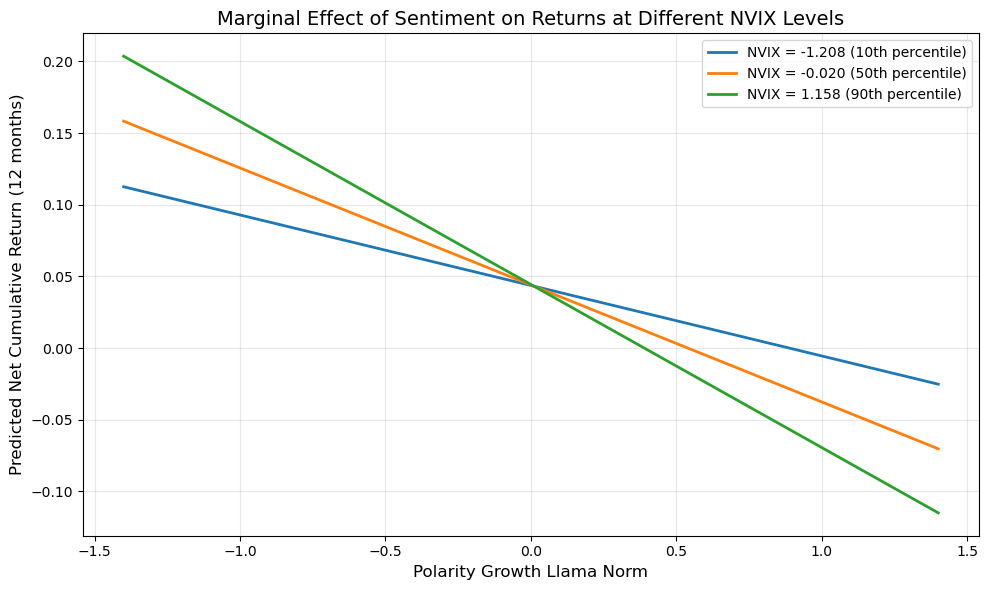

In [88]:
plot_prediction_for_different_risks(df=nvix[mask], 
                                    model_results=res_v,
                                    x_vars=['polarity_growth_llama_norm', 'nvix_norm', 'sent_nvix'],
                                    risk_col='nvix_norm',
                                    polarity_values=np.linspace(-1.4, 1.4, 100),
                                    risk_name='NVIX',
                                    xlabel='Polarity Growth Llama Norm',
                                    ylabel='Predicted Net Cumulative Return (12 months)'
                                   )

## Recession

In [89]:
rec = pd.read_excel('SENTIMENT.xlsx')

rec = rec[['yearmo', 'recess']]
rec['year_month'] = pd.to_datetime(rec['yearmo'], format='%Y%m')

In [90]:
rec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 792 entries, 0 to 791
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   yearmo      792 non-null    int64         
 1   recess      792 non-null    int64         
 2   year_month  792 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(2)
memory usage: 18.7 KB


In [91]:
rec.tail()

,yearmo,recess,year_month
787,202308,0,2023-08-01
788,202309,0,2023-09-01
789,202310,0,2023-10-01
790,202311,0,2023-11-01
791,202312,0,2023-12-01


In [92]:
data_r = data.merge(rec, on='year_month', how='left')
data_r['sent_rec'] = data_r['polarity_growth_llama_norm'] * data_r['recess']

In [93]:
features_res, table_res = fit_one_factor(data_r, 'polarity_growth_llama_norm', return_names, ['recess', 'sent_rec'])
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.007***,-3.011,19.131,0.003
net_cum_return3,-0.017***,-3.455,22.27,0.001
net_cum_return6,-0.026***,-3.097,27.315,0.002
net_cum_return9,-0.039***,-3.594,31.562,0.0
net_cum_return12,-0.056***,-3.905,31.894,0.0
net_cum_return24,-0.098***,-2.831,27.014,0.005
net_cum_return36,-0.128**,-2.384,26.378,0.017


In [94]:
res_r = ols_new_west(data_r, x_vars=['polarity_growth_llama_norm', 'recess', 'sent_rec'], target='net_cum_return1')
print(res_r.summary())

                            OLS Regression Results                            
Dep. Variable:        net_cum_return1   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     8.816
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.41e-05
Time:                        21:16:47   Log-Likelihood:                 377.42
No. Observations:                 252   AIC:                            -746.8
Df Residuals:                     248   BIC:                            -732.7
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           